# **Spotify Songs’ Genre Segmentation**

# **Introduction**

Music streaming platforms generate massive amounts of data every day. Spotify, one of the most popular music streaming applications, uses intelligent recommendation systems to suggest songs based on user preferences and listening history. These recommendations are driven by audio features extracted from songs and machine learning algorithms that group similar songs together.

The objective of this minor project is to analyze a Spotify songs dataset, perform data preprocessing, visualize important characteristics, apply clustering techniques to segment songs into meaningful groups, and demonstrate how these clusters can be used to build a basic recommendation system.

## **Dataset Description**

The dataset used in this project consists of approximately 32,000 Spotify tracks with 23 attributes. These attributes describe both the musical properties and metadata of each song.

**Key Attributes:**

**Categorical Features:**

playlist_genre, playlist_name, track_artist

**Numerical Audio Features:**

danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms, track_popularity

These audio features are generated using Spotify’s audio analysis algorithms and are essential for clustering and recommendation.

# **Data Preprocessing**

Before applying machine learning algorithms, the dataset was preprocessed to ensure data quality and consistency.

In [ ]:
import pandas as pd
import numpy as np

“Upload spotify dataset.csv before running the notebook.”

In [ ]:
df = pd.read_csv("spotify dataset.csv")
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


Handling Missing Values: The dataset was checked for missing values.

In [ ]:
df.isnull().sum()


,0
track_id,0
track_name,5
track_artist,5
track_popularity,0
track_album_id,0
track_album_name,5
track_album_release_date,0
playlist_name,0
playlist_id,0
playlist_genre,0


Removing Duplicates: Duplicate records were removed to avoid bias in analysis.

In [ ]:
df = df.drop_duplicates()

Feature Selection: Only numerical audio features relevant to song similarity were selected for clustering.

In [ ]:
features = [
    'danceability','energy','loudness','speechiness',
    'acousticness','instrumentalness','liveness',
    'valence','tempo','duration_ms'
]
X = df[features]

Feature Scaling: Standardization was applied using StandardScaler to bring all numerical features to a common scale.

Scaling is required because features like loudness and tempo have different ranges.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Exploratory Data Analysis and Visualization**

Data visualization was performed to understand the distribution of features and uncover meaningful patterns.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

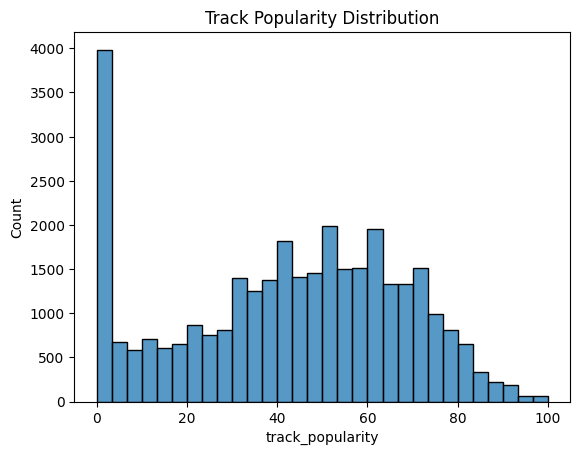

In [ ]:
# Popularity distribution

sns.histplot(df['track_popularity'], bins=30)
plt.title("Track Popularity Distribution")
plt.show()

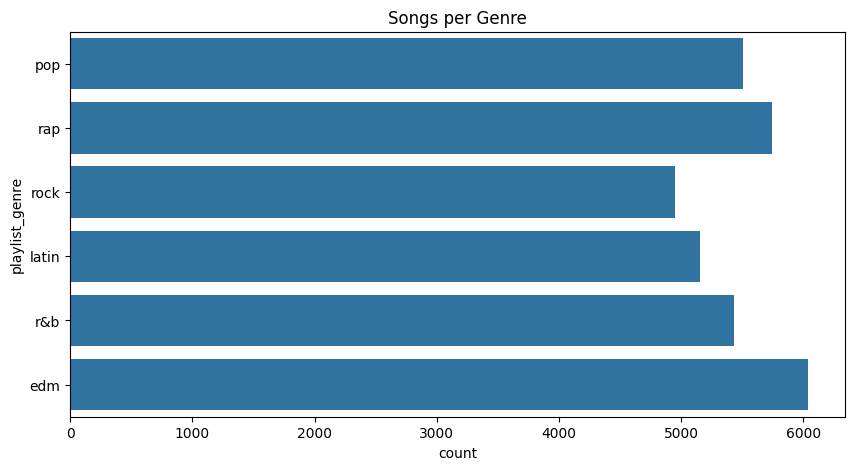

In [ ]:
# Genre-wise Song Count

plt.figure(figsize=(10,5))
sns.countplot(y='playlist_genre', data=df)
plt.title("Songs per Genre")
plt.show()

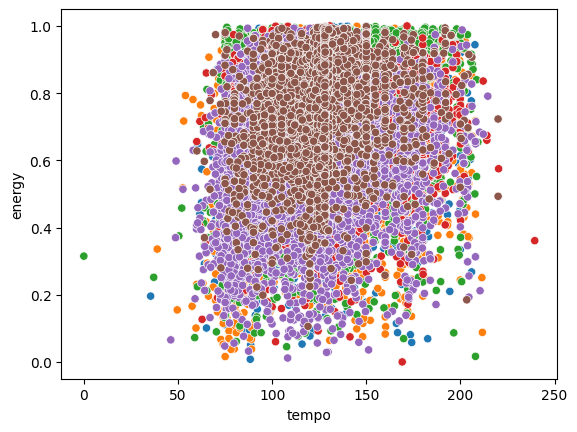

In [ ]:
# Tempo vs Energy

sns.scatterplot(x='tempo', y='energy', hue='playlist_genre', data=df, legend=False)
plt.show()

### **Key Observations:**

Pop and EDM genres generally exhibit higher energy and danceability.

Acoustic tracks tend to have lower energy and tempo.

Track popularity varies widely across genres, indicating that popularity alone is not sufficient for recommendations.

# **Correlation Analysis**

A correlation matrix was generated to understand the relationships between numerical audio features.

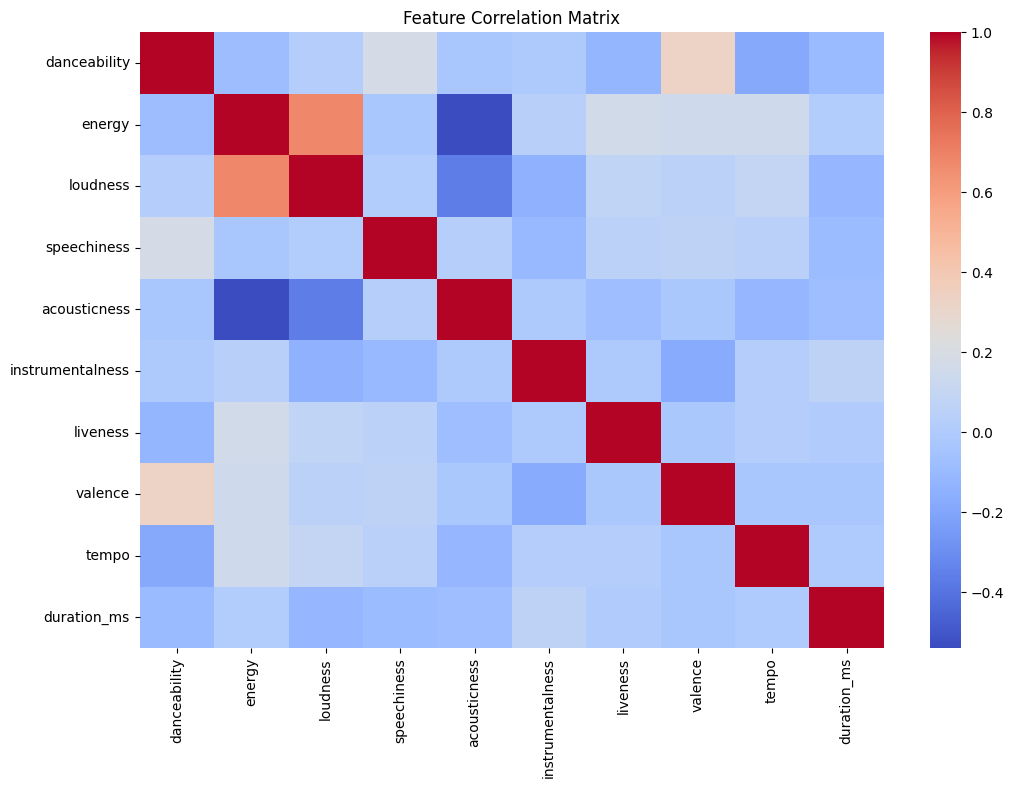

In [ ]:
plt.figure(figsize=(12,8))
corr = df[features].corr()

sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()


### **Observations:**

Energy and loudness show a strong positive correlation.

Acousticness is negatively correlated with energy and loudness.

Danceability and valence have a moderate positive correlation.

# **Clustering Using K-Means**

Unsupervised learning was applied to segment songs into clusters based on audio similarity.

**Elbow Method:**

The Elbow Method was used to determine the optimal number of clusters. Based on the WCSS plot, the optimal number of clusters was selected as 5.

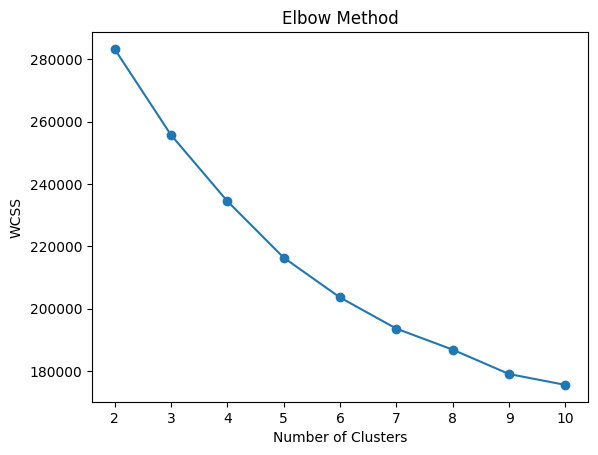

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


**K-Means Clustering:**

K-Means clustering was applied to the scaled audio features, and each song was assigned a cluster label.

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


**Cluster Visualization:**

Principal Component Analysis (PCA) was used to reduce the data to two dimensions for visualization. The scatter plot revealed well-separated clusters, indicating effective segmentation.

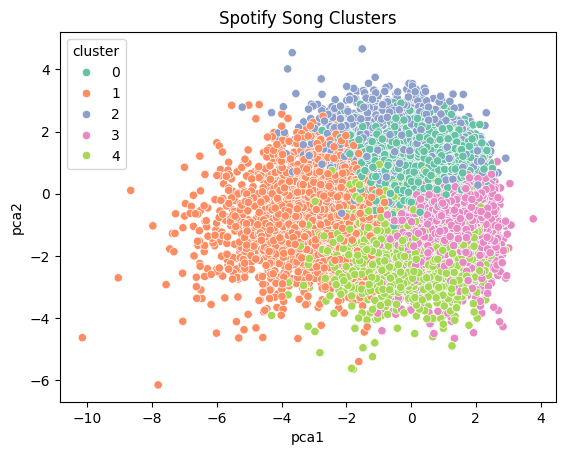

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

df['pca1'] = pca_data[:,0]
df['pca2'] = pca_data[:,1]

sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df, palette='Set2')
plt.title("Spotify Song Clusters")
plt.show()


Songs with similar audio features are grouped together into clusters.

# **Cluster Interpretation with Genres and Playlists**

Clusters were compared with playlist genres and playlist names to understand their composition.

In [ ]:
pd.crosstab(df['cluster'], df['playlist_genre'])


playlist_genre,edm,latin,pop,r&b,rap,rock
cluster,,,,,,
0,1395,3036,2323,2128,1574,1289
1,222,579,827,1624,709,948
2,312,630,274,924,2448,49
3,2622,715,1784,649,780,2420
4,1492,195,299,106,235,245



**Findings:**

Certain clusters were dominated by specific genres such as Pop or EDM.

Some clusters contained mixed genres, demonstrating that songs from different genres can share similar audio characteristics.

This behavior aligns with Spotify’s recommendation approach, which focuses on sound similarity rather than strict genre boundaries.

# **Recommendation System Design**

A simple content-based recommendation system was implemented using cosine similarity.

**Methodology:**

Audio feature vectors of songs were compared using cosine similarity.

Given a song, the system recommends other songs with the highest similarity scores.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

song_index = 10   # any song index
similarity = cosine_similarity([X_scaled[song_index]], X_scaled)

similar_songs = similarity.argsort()[0][-6:-1]
df.iloc[similar_songs][['track_name','track_artist','playlist_genre']]


,track_name,track_artist,playlist_genre
26267,Magic,Yung Bae,r&b
27407,Very Nice People,DJ Mibor,edm
29717,If You're Over Me - Sebastian Perez Remix,Years & Years,edm
2907,DJ Got Us Fallin' In Love (feat. Pitbull),Usher,pop
10880,Padrinhos Mágicos,Ecologyk,rap


The system recommends songs based on similarity of audio features rather than popularity.

**Advantages:**

Recommendations are based on musical characteristics rather than popularity.

Works effectively for discovering songs with similar sound profiles.

# **Results and Discussion**

The clustering model successfully grouped songs with similar audio features. The alignment between clusters and genres validates the effectiveness of the approach. The recommendation system demonstrates how clustered audio features can be leveraged to suggest relevant songs to users.

# **Conclusion**

This project demonstrated the use of data preprocessing, visualization, correlation analysis, and unsupervised machine learning to analyze Spotify song data. By applying K-Means clustering, songs were grouped into meaningful clusters based on audio features. A basic content-based recommendation system was built using these features, showcasing how music recommendation systems work in real-world applications.